In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def log_likelihood_mix(vr, mu1, sig1, mu2, sig2, f, e_vr=0):
    var1 = sig1 ** 2 + e_vr ** 2
    var2 = sig2 ** 2 + e_vr ** 2
    p1 = np.exp(-0.5 * ((vr - mu1) ** 2 / var1 + np.log(2 * np.pi * var1)))
    p2 = np.exp(-0.5 * ((vr - mu2) ** 2 / var2 + np.log(2 * np.pi * var2)))
    total_p = f * p1 + (1-f) * p2 + 1e-30
    return np.sum(np.log(total_p))

In [ ]:
def metropolis_mix(vr_data, e_vr=0, n_samples=10000,
                   mu1_init=-200, sig1_init=5,
                   mu2_init=0, sig2_init=1,
                   f_init=0.7, clip=0,
                   mu_step=1, sig_step=1, f_step=0.05):
    count_accepted = 0
    chain = np.zeros((n_samples, 6))
    logL0 = log_likelihood_mix(vr_data, mu1_init, sig1_init, mu2_init, sig2_init, f_init, e_vr)
    chain[0] = [mu1_init, sig1_init, mu2_init, sig2_init, f_init, logL0]

    for i in range(1, n_samples):
        mu1_now, sig1_now, mu2_now, sig2_now, f_now, logL_now = chain[i-1]
        mu1_prop = np.random.normal(mu1_now, mu_step)
        sig1_prop = np.random.normal(sig1_now, sig_step)
        mu2_prop = np.random.normal(mu2_now, mu_step)
        sig2_prop = np.random.normal(sig2_now, sig_step)
        f_prop = np.random.normal(f_now, f_step)

        if sig1_prop <= 0 or sig2_prop <= 0:
            chain[i] = chain[i-1]
            continue
        if f_prop <= 0 or f_prop >= 1:
            chain[i] = chain[i-1]
            continue

        if not (mu1_prop < -200 and mu2_prop > -200):
            chain[i] = chain[i-1]
            continue


        logL_prop = log_likelihood_mix(vr_data, mu1_prop, sig1_prop, mu2_prop, sig2_prop, f_prop, e_vr)
        accept_alpha = min(1, np.exp(logL_prop - logL_now))
        rand_u = np.random.rand()
        if rand_u < accept_alpha:
            count_accepted += 1
            chain[i] = [mu1_prop, sig1_prop, mu2_prop, sig2_prop, f_prop, logL_prop]
        else:
            chain[i] = chain[i-1]
    print(f"接受率: {count_accepted / n_samples:.3f}")
    return chain[clip:]

In [4]:
def calculate_mix(set_path, num=None, mu_step=1, sig_step=1, f_step=0.05,
                  n_samples=10000, mu1_init=-380, sig1_init=30,
                  mu2_init=-100, sig2_init=40, f_init=0.3, clip=0):
    df = pd.read_csv(set_path)
    if num is None:
        vr_data = df["vr"].values
        e_vr = df["e_vr"].values
    else:
        vr_data = df["vr"].values[:num]
        e_vr = df["e_vr"].values[:num]
    print(f"数据整体均值: {vr_data.mean():.2f}, 数据整体标准差: {vr_data.std():.2f}")
    chain = metropolis_mix(vr_data, e_vr=e_vr, n_samples=n_samples,
                           mu1_init=mu1_init, sig1_init=sig1_init,
                           mu2_init=mu2_init, sig2_init=sig2_init,
                           f_init=f_init, clip=clip,
                           mu_step=mu_step, sig_step=sig_step, f_step=f_step)
    mu1_all = chain[:, 0]
    sig1_all = chain[:, 1]
    mu2_all = chain[:, 2]
    sig2_all = chain[:, 3]
    f_all = chain[:, 4]
    iter_index = np.arange(len(chain))
    plt.figure(figsize=(5, 3))
    sc = plt.scatter(mu1_all, sig1_all, c=iter_index, cmap="jet", s=8)
    plt.xlabel(r"$\mu_1$ (Dwarf mean vr)")
    plt.ylabel(r"$\sigma_1$ (Dwarf dispersion)")
    plt.title("Metropolis: Dwarf Component")
    plt.colorbar(sc, label="iteration_nb")
    start_mu1, start_sig1 = chain[0, 0], chain[0, 1]
    end_mu1, end_sig1 = chain[-1, 0], chain[-1, 1]
    plt.plot(start_mu1, start_sig1, "ko", markersize=10, markeredgecolor="white")
    plt.plot(end_mu1, end_sig1, "ro", markersize=10, markeredgecolor="white")
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(5, 3))
    sc2 = plt.scatter(mu2_all, sig2_all, c=iter_index, cmap="jet", s=8)
    plt.xlabel(r"$\mu_2$ (MW mean vr)")
    plt.ylabel(r"$\sigma_2$ (MW dispersion)")
    plt.title("Metropolis: Milky Way Component")
    plt.colorbar(sc2, label="iteration_nb")
    start_mu2, start_sig2 = chain[0, 2], chain[0, 3]
    end_mu2, end_sig2 = chain[-1, 2], chain[-1, 3]
    plt.plot(start_mu2, start_sig2, "ko", markersize=10, markeredgecolor="white")
    plt.plot(end_mu2, end_sig2, "ro", markersize=10, markeredgecolor="white")
    plt.tight_layout()
    plt.show()


    mu1 = np.mean(mu1_all)
    sig1 = np.mean(sig1_all)
    mu2 = np.mean(mu2_all)
    sig2 = np.mean(sig2_all)
    f = np.mean(f_all)
    e_mean = np.mean(e_vr)
    x_grid = np.linspace(vr_data.min()-50, vr_data.max()+50, 1000)
    var1 = sig1**2 + e_mean**2
    var2 = sig2**2 + e_mean**2
    g1 = np.exp(-0.5 * ((x_grid - mu1) ** 2 / var1)) / np.sqrt(2 * np.pi * var1)
    g2 = np.exp(-0.5 * ((x_grid - mu2) ** 2 / var2)) / np.sqrt(2 * np.pi * var2)
    comp1 = f * g1
    comp2 = (1 - f) * g2
    total = comp1 + comp2
    plt.figure(figsize=(10, 5))
    plt.hist(vr_data, bins=80, density=True, alpha=0.5)
    plt.plot(x_grid, total, "r", lw=2)
    plt.plot(x_grid, comp1, "g--", lw=1.5)
    plt.plot(x_grid, comp2, "b--", lw=1.5)
    plt.xlabel("Radial velocity (km/s)")
    plt.ylabel("Density")
    plt.legend(["Observed VR data","Total mixed model","Dwarf component","MW component"])
    plt.grid(alpha=0.3)
    plt.title("Velocity Distribution & MCMC Fit")
    plt.tight_layout()
    plt.show()


    print("===== 初始参数 =====")
    print(f"矮星系 start_mu1:{start_mu1:.2f}, start_sig1:{start_sig1:.2f}")
    print(f"银河系 start_mu2:{start_mu2:.2f}, start_sig2:{start_sig2:.2f}")
    print(f"矮星系初始占比 f_init:{chain[0,4]:.3f}")
    print("===== 链条末尾参数 =====")
    print(f"矮星系 end_mu1:{end_mu1:.2f}, end_sig1:{end_sig1:.2f}")
    print(f"银河系 end_mu2:{end_mu2:.2f}, end_sig2:{end_sig2:.2f}")
    print(f"矮星系末尾占比 f_end:{chain[-1,4]:.3f}")
    print("===== 后验均值 =====")
    print(f"矮星系 mu1_mean:{np.mean(mu1_all):.2f}, sig1_mean:{np.mean(sig1_all):.2f}")
    print(f"银河系 mu2_mean:{np.mean(mu2_all):.2f}, sig2_mean:{np.mean(sig2_all):.2f}")
    print(f"矮星系平均占比 f_mean:{np.mean(f_all):.3f}")
    return chain

数据整体均值: -276.70, 数据整体标准差: 136.90


C:\Users\32166\AppData\Local\Temp\ipykernel_33800\2823951555.py:32: RuntimeWarning: overflow encountered in exp
  accept_alpha = min(1, np.exp(logL_prop - logL_now))


接受率: 0.013


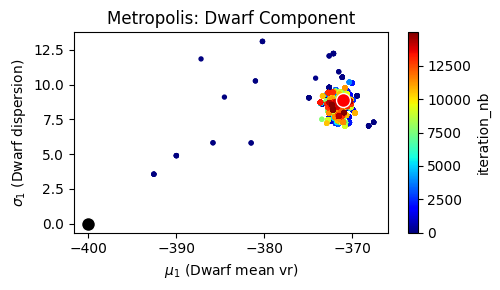

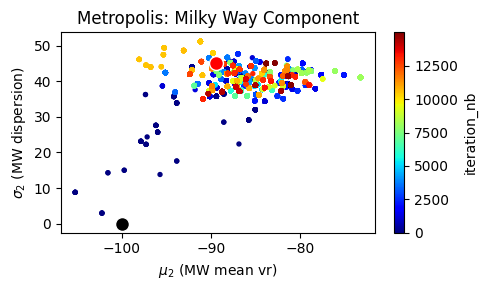

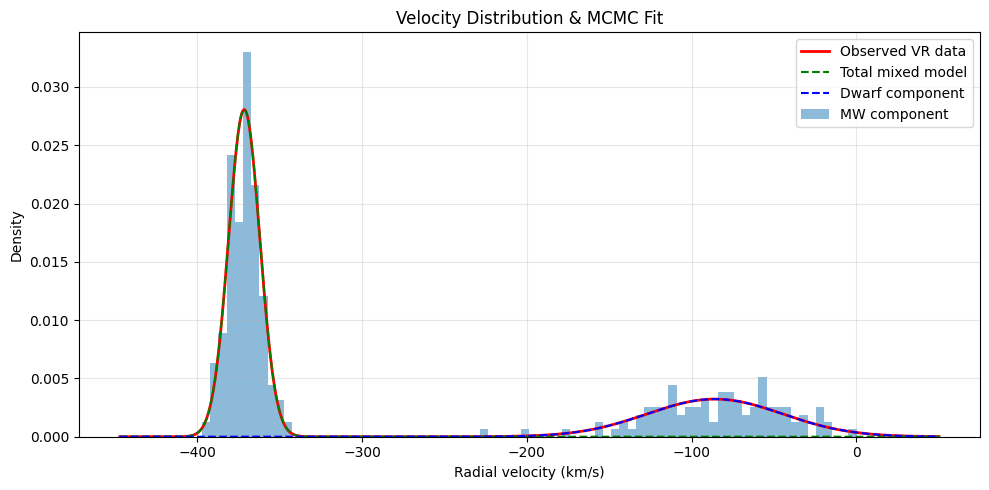

===== 初始参数 =====
矮星系 start_mu1:-400.00, start_sig1:0.00
银河系 start_mu2:-100.00, start_sig2:0.00
矮星系初始占比 f_init:0.300
===== 链条末尾参数 =====
矮星系 end_mu1:-371.06, end_sig1:8.87
银河系 end_mu2:-89.48, end_sig2:45.16
矮星系末尾占比 f_end:0.660
===== 后验均值 =====
矮星系 mu1_mean:-371.54, sig1_mean:8.39
银河系 mu2_mean:-85.87, sig2_mean:40.84
矮星系平均占比 f_mean:0.668


In [5]:
chain_output = calculate_mix(
    set_path="data/cas3_total.csv",
    num=None,
    n_samples=15000,
    mu_step=5, sig_step=5, f_step=0.03,
    mu1_init=-400, sig1_init=0,
    mu2_init=-100, sig2_init=0,
    f_init=0.3,
    clip=0
)